In [4]:
import pandas as pd

# 1. Load the dataset with low_memory=False to handle mixed types warning
df = pd.read_csv('SSC_merged_no_blank_keys.csv', low_memory=False)

# 2. Define the mapping using the EXACT raw strings from your index list
column_mapping = {
    "Project key": "project_key",
    # Demographic
    "Age at study visit (automatic calculated field):    Âge au moment de la visite d'étude (champ calculé automatiquement):": "age_at_visit",
    "1. Gender/Genre:": "gender",
    # Clinical
    "What is the current duration of disease? (years)    Quelle est la durée actuelle de la maladie? (years)": "disease_duration",
    "What is the age at diagnosis? (years)    Quel est l'âge du diagnostic? (années)": "age_at_diagnosis",
    "9. What symptoms are currently present?    9. Quels sont les symptômes présents actuellement?": "current_symptoms",
    "8. When the symptoms began, did the symptoms present on one side or both sides of your body?    8. Les symptômes sont-ils apparus d'un seul côté ou des deux côté de votre corps?": "symptom_laterality",
    "8. Do you feel or have people told you that your sense of smell is getting worse?    8. Avez-vous remarqué ou vous a-t-on fait remarquer que vous aviez une perte d'odorat?": "smell_loss",
    "6. What is your dominant hand?    6. Quelle est votre main dominante?": "dominant_hand",
    "20. Do you exercise on a regular basis?    20. Faites-vous de l\'exercice régulièrement?": "exercise",
    "23. Do you currently drink coffee?    23. Buvez-vous du café régulièrement?": "coffee_drinker",
    # MoCA
    "TOTAL SCORE (make sure to include extra point for 12 years or less of education):    SCORE TOTAL (assurez-vous d'inclure un point supplémentaire pour 12 ans ou moins d'éducation) :.x": "moca_total",
    # BDI-II
    "BDI-II Total Score": "bdi_total",
    # MBI-C (Note: using the version with the .x suffix found in your list)
    "MBI-C Grand Total.x": "mbi_total",
    # EHI
    "EHI Handedness Score": "ehi_score",
    # Outcome
    "Enrolment Group:    Groupe d'inscription:": "outcome"
}


# 3. Filter and Rename
# We use a list comprehension to ensure we only grab keys that actually exist in the dataframe
available_cols = [col for col in column_mapping.keys() if col in df.columns]
df_filtered = df[available_cols].copy()
df_filtered.rename(columns=column_mapping, inplace=True)

# 4. Clean the Outcome Variable
# This removes leading/trailing spaces and ensures consistent categories
df_filtered['outcome'] = df_filtered['outcome'].str.strip()

# 5. Review the results
print(f"Successfully extracted {len(df_filtered.columns)} variables.")
print(df_filtered['outcome'].value_counts())
print(df_filtered.head())

Successfully extracted 16 variables.
outcome
PD (Parkinson's Disease)/(Maladie de Parkinson)        2852
Healthy control/Contrôle                                410
AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)     171
Name: count, dtype: int64
  project_key  age_at_visit          gender  disease_duration  \
0     SSC0001          50.0   Male/Masculin              14.0   
1     SSC0002          65.0  Female/Féminin              11.3   
2     SSC0003          66.0   Male/Masculin              19.6   
3     SSC0004          53.0   Male/Masculin               9.8   
4     SSC0005          52.0   Male/Masculin               9.6   

   age_at_diagnosis                                   current_symptoms  \
0              45.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
1              62.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
2              54.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
3              50.0  Tremor/Tremblements,Muscle stiffness (Rig

In [6]:
import pandas as pd
import numpy as np
%pip install jinja2

# 1. Define Groups and Columns
# Ensure 'outcome' is clean
#df_filtered['outcome'] = df_filtered['outcome'].fillna('Unknown')
unique_groups = [g for g in df_filtered['outcome'].unique() if g != 'Unknown']

numeric_cols = ['age_at_visit', 'age_at_diagnosis', 'disease_duration', 'moca_total', 'bdi_total', 'mbi_total', 'ehi_score']
categorical_cols = ['gender', 'smell_loss', 'dominant_hand', "exercise", "coffee_drinker"]

def get_stats(df, label):
    """Calculates Mean (SD) or Count (%) and handles empty/NaN values."""
    stats = {}
    n = len(df)
    stats['Sample Size (n)'] = int(n)
    
    # Numeric Logic
    for col in numeric_cols:
        if col in df.columns:
            val = df[col].dropna()
            if len(val) > 0:
                stats[col] = f"{val.mean():.2f} ({val.std():.2f})"
            else:
                stats[col] = "---" # Cleaner than NaN/empty
                
    # Categorical Logic (showing top result for brevity)
    for col in categorical_cols:
        if col in df.columns:
            counts = df[col].value_counts()
            if not counts.empty:
                top_cat = counts.index[0]
                count = counts.iloc[0]
                perc = (count / n) * 100
                stats[f"{col} ({top_cat})"] = f"{count} ({perc:.1f}%)"
            else:
                stats[f"{col}"] = "---"
                
    return pd.Series(stats, name=label)

# 2. Generate Columns
# Generate 'Overall' first
overall_col = get_stats(df_filtered, 'Overall')

# Generate individual group columns
group_cols = [get_stats(df_filtered[df_filtered['outcome'] == g], g) for g in unique_groups]

# 3. Concatenate and Clean
table_1 = pd.concat([overall_col] + group_cols, axis=1)

# FINAL FIX: Remove any rows that are entirely "---" or empty across all columns
table_1 = table_1.replace("---", np.nan).dropna(how='all').fillna("---")

import pandas as pd
import numpy as np

# 1. Generate the table using the logic from our previous step
# (Assuming 'table_1' is the DataFrame we built)

def format_as_kable(df):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]}
    ]).set_caption("Table 1: Clinical Characteristics and Demographics") \
      .set_table_attributes('style="border-collapse: collapse; width: 100%;"')

# Display in Notebook
formatted_table = format_as_kable(table_1)
formatted_table

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jinja2]
Note: you may need to restart the kernel to use updated packages.


,Overall,PD (Parkinson's Disease)/(Maladie de Parkinson),Healthy control/Contrôle,AP (Atypical Parkinsonism)/(Parkinsonisme Atypique),nan
Sample Size (n),3541,2852,410,171,0
age_at_visit,66.20 (10.04),66.59 (9.59),62.54 (12.22),66.64 (11.71),---
age_at_diagnosis,60.73 (10.42),60.60 (10.25),---,63.26 (12.98),---
disease_duration,9.64 (6.01),9.83 (5.98),---,6.05 (5.50),---
moca_total,26.70 (2.71),26.58 (2.53),27.78 (3.15),22.00 (nan),---
bdi_total,9.65 (7.53),9.66 (7.35),6.24 (5.93),16.76 (10.45),---
mbi_total,0.94 (4.22),0.93 (4.09),0.33 (2.01),3.24 (8.62),---
ehi_score,0.71 (0.46),0.72 (0.44),0.66 (0.56),0.72 (0.50),---
gender (Male/Masculin),1804 (50.9%),1612 (56.5%),---,78 (45.6%),---
smell_loss (No/Non),1004 (28.4%),762 (26.7%),170 (41.5%),70 (40.9%),---


# Models

### Cross Validation

Three class classification directly, PD, PD-plus and healthy controls


 MODEL: Logistic Regression 
 5-Fold CV Macro F1: 0.464 (+/- 0.030)
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.10      0.41      0.16        34
                           Healthy control/Contrôle       0.45      0.91      0.60        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.94      0.62      0.75       571

                                           accuracy                           0.65       687
                                          macro avg       0.50      0.65      0.50       687
                                       weighted avg       0.84      0.65      0.70       687


 MODEL: Random Forest 
 5-Fold CV Macro F1: 0.485 (+/- 0.017)
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.10      0.24      0.14        34
                           

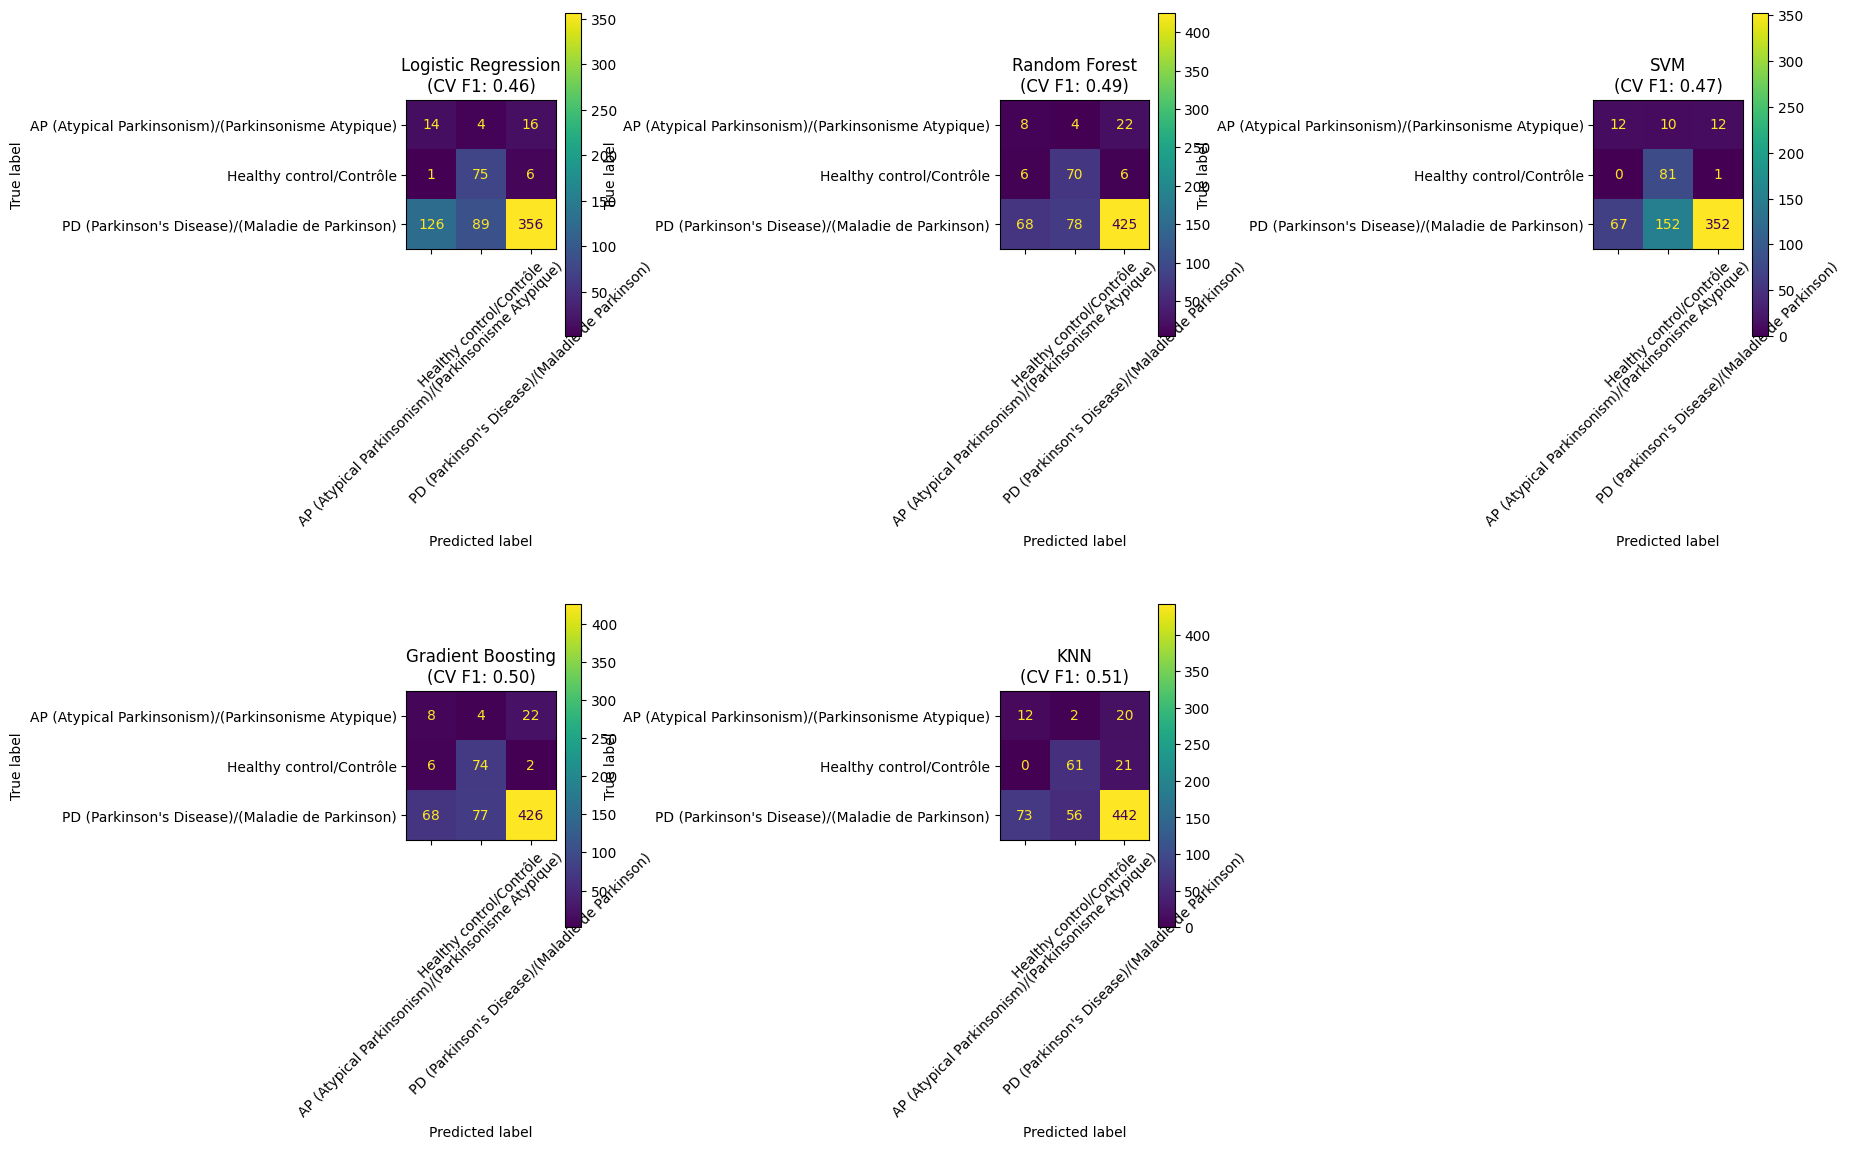

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# imblearn is required for SMOTE within a pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- 1. Clean Data & Encode Target ---
df_ml = df_filtered.dropna(subset=['outcome']).copy()
df_ml['outcome'] = df_ml['outcome'].str.strip()

le = LabelEncoder()
y = le.fit_transform(df_ml['outcome'])
X = df_ml.drop(columns=['outcome', 'project_key'])

# --- 2. Define Feature Groups ---
numeric_features = ['age_at_visit', 'age_at_diagnosis', 'disease_duration', 
                    'moca_total', 'bdi_total', 'mbi_total', 'ehi_score']
categorical_features = ['gender', 'smell_loss', 'dominant_hand', 'symptom_laterality']

# --- 3. Preprocessing Transformers ---
num_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

# --- 4. Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# --- 5. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# --- 6. Execution with SMOTE and Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a 2x3 grid to fit 5 models comfortably
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten to 1D array for easier indexing in the loop

for i, (name, clf) in enumerate(models.items()):
    pipeline = ImbPipeline(steps=[
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])
    
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n" + "="*45)
    print(f" MODEL: {name} ")
    print(f" 5-Fold CV Macro F1: {cv_results.mean():.3f} (+/- {cv_results.std():.3f})")
    print("="*45)
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        display_labels=le.classes_, 
        cmap='viridis', 
        ax=axes[i], 
        xticks_rotation=45
    )
    axes[i].set_title(f"{name}\n(CV F1: {cv_results.mean():.2f})")

# Remove the empty 6th subplot
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

This first classifies patietns into healthy or with parkinsonism. Then it takes the ones with parkinsonism and classifies them into PD and PD-plus

Problem 1 Class Counts:
 binary_outcome
1    3023
0     410
Name: count, dtype: int64

[Healthy vs. Parkinsonism] MODEL: Logistic Regression
              precision    recall  f1-score   support

     Healthy       0.37      0.85      0.52        82
Parkinsonism       0.98      0.80      0.88       605

    accuracy                           0.81       687
   macro avg       0.67      0.83      0.70       687
weighted avg       0.90      0.81      0.84       687


[Healthy vs. Parkinsonism] MODEL: Random Forest
              precision    recall  f1-score   support

     Healthy       0.39      0.80      0.53        82
Parkinsonism       0.97      0.83      0.90       605

    accuracy                           0.83       687
   macro avg       0.68      0.82      0.71       687
weighted avg       0.90      0.83      0.85       687


[Healthy vs. Parkinsonism] MODEL: SVM
              precision    recall  f1-score   support

     Healthy       0.30      1.00      0.46        82
Parkinso

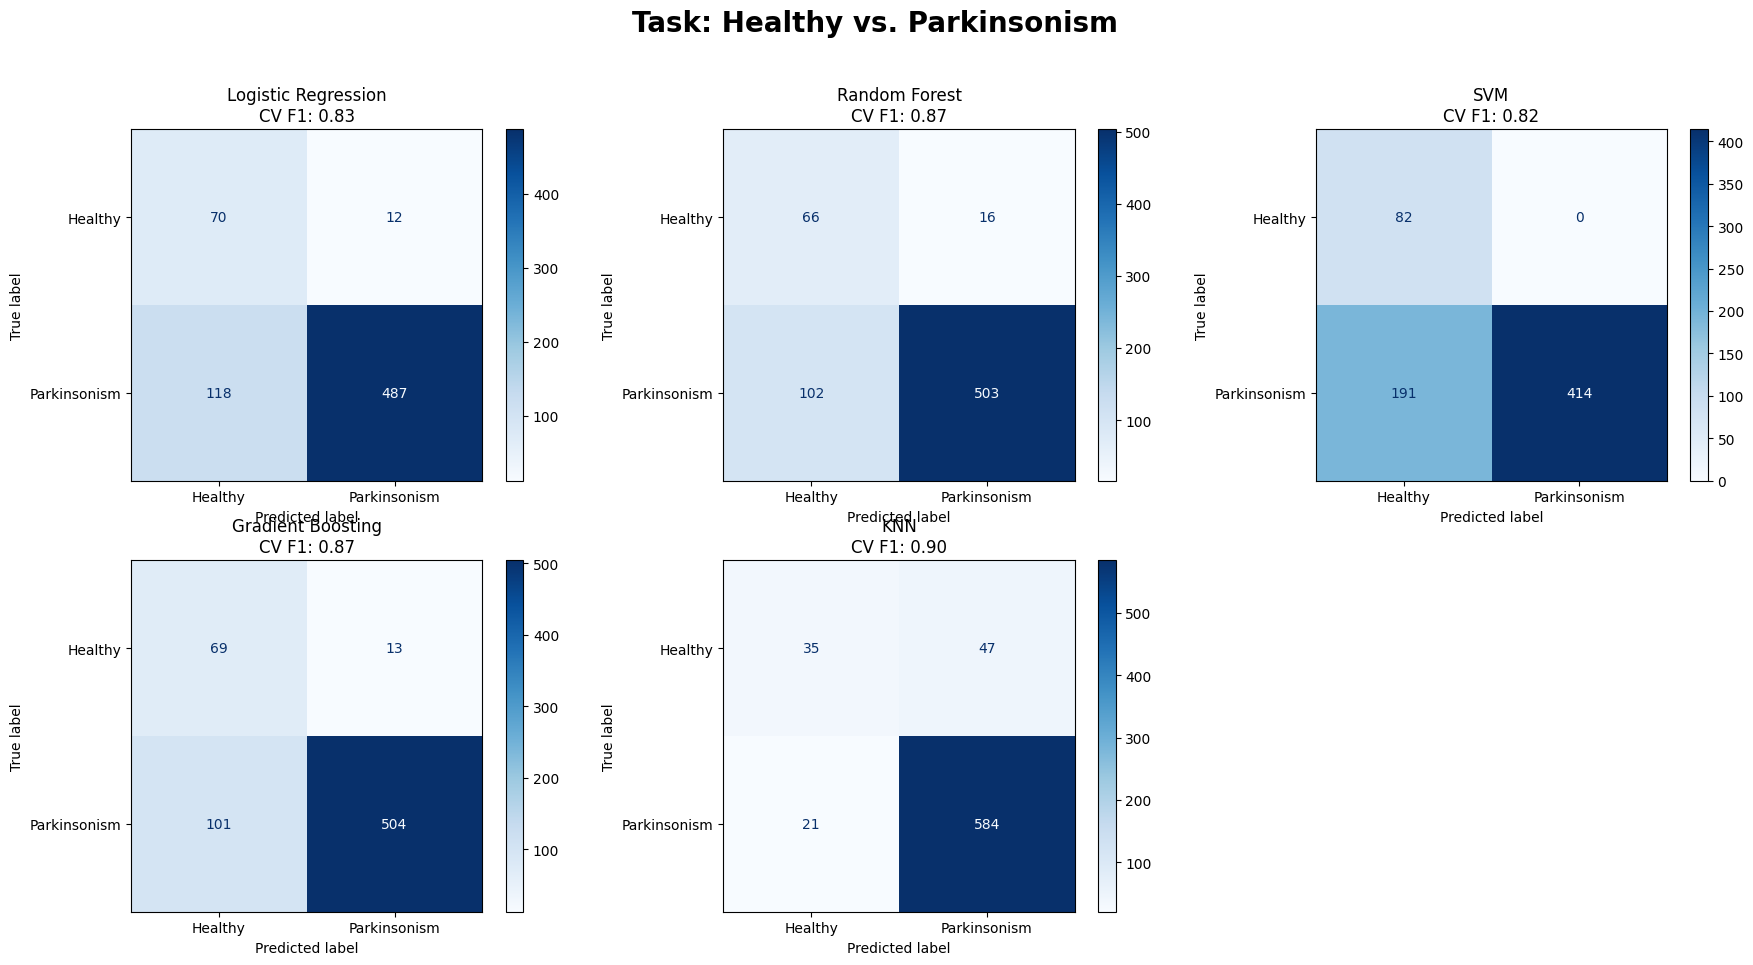

Problem 2 Class Counts:
 binary_outcome
0    2852
1     171
Name: count, dtype: int64

[PD vs. PD Plus] MODEL: Logistic Regression
              precision    recall  f1-score   support

          PD       0.95      0.66      0.78       571
     PD Plus       0.08      0.47      0.13        34

    accuracy                           0.65       605
   macro avg       0.52      0.57      0.46       605
weighted avg       0.91      0.65      0.75       605


[PD vs. PD Plus] MODEL: Random Forest
              precision    recall  f1-score   support

          PD       0.96      0.80      0.87       571
     PD Plus       0.10      0.38      0.16        34

    accuracy                           0.77       605
   macro avg       0.53      0.59      0.51       605
weighted avg       0.91      0.77      0.83       605


[PD vs. PD Plus] MODEL: SVM
              precision    recall  f1-score   support

          PD       0.96      0.62      0.75       571
     PD Plus       0.08      0.56     

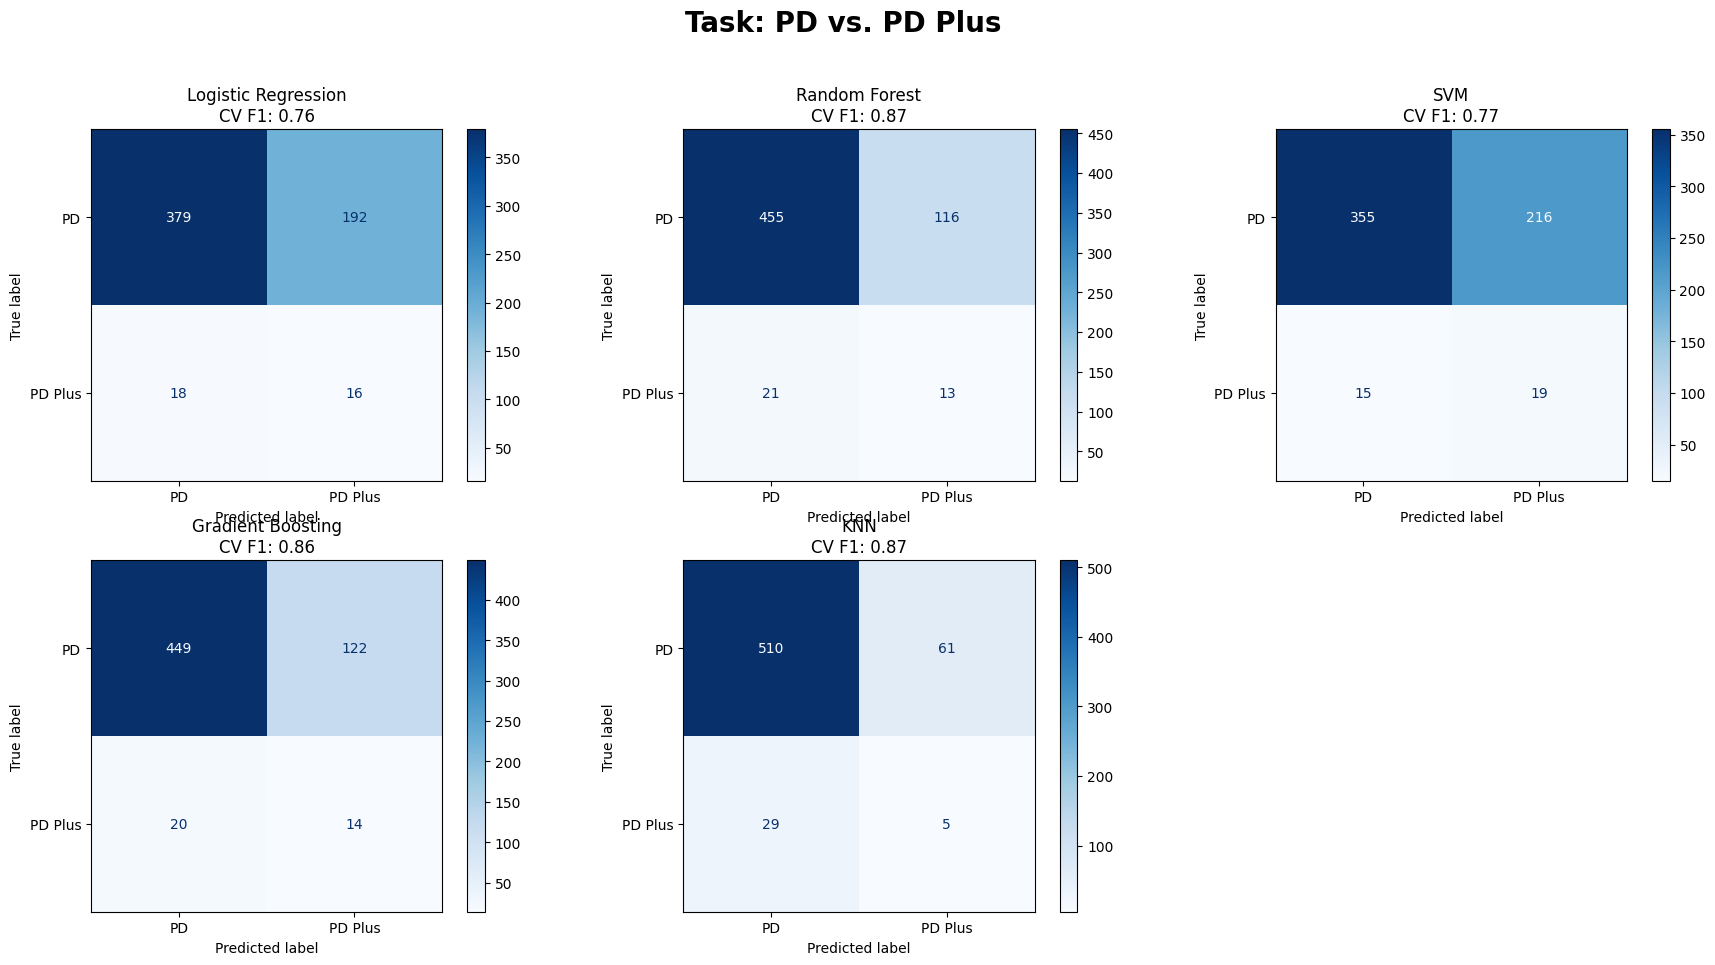

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Model Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- 1. Data Preparation ---
# Cleaning and stripping
df_ml = df_filtered.dropna(subset=['outcome']).copy()
df_ml['outcome'] = df_ml['outcome'].str.strip()

# Define shared feature groups
numeric_features = ['age_at_visit', 'age_at_diagnosis', 'disease_duration', 
                    'moca_total', 'bdi_total', 'mbi_total', 'ehi_score']
categorical_features = ['gender', 'smell_loss', 'dominant_hand', 'symptom_laterality']

# --- 2. Preprocessing Transformers ---
num_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

# --- 3. Models Definition ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# --- 4. Unified Execution Function ---
def run_binary_classification(X_data, y_data, title, class_names):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, stratify=y_data, random_state=42
    )
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Task: {title}', fontsize=20, fontweight='bold')
    axes = axes.flatten()

    for i, (name, clf) in enumerate(models.items()):
        pipeline = ImbPipeline(steps=[
            ('pre', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('clf', clf)
        ])
        
        cv_results = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_weighted')
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        print(f"\n[{title}] MODEL: {name}")
        print(classification_report(y_test, y_pred, target_names=class_names))
        
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, 
            display_labels=class_names, 
            cmap='Blues', 
            ax=axes[i]
        )
        axes[i].set_title(f"{name}\nCV F1: {cv_results.mean():.2f}")

    if len(models) < len(axes):
        fig.delaxes(axes[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 5. PROBLEM 1: Healthy vs. All Parkinsonism ---
df_p1 = df_ml.copy()

# The mapping needs to match your exact string labels
# We classify 'Healthy control/Contrôle' as 0, and everything else as 1
df_p1['binary_outcome'] = df_p1['outcome'].apply(
    lambda x: 0 if 'Healthy control' in x else 1
)

# Debug print to ensure we actually have two classes now
print("Problem 1 Class Counts:\n", df_p1['binary_outcome'].value_counts())

X1 = df_p1.drop(columns=['outcome', 'project_key', 'binary_outcome'])
y1 = df_p1['binary_outcome']

# Run the classification
run_binary_classification(X1, y1, "Healthy vs. Parkinsonism", ["Healthy", "Parkinsonism"])


# --- 6. PROBLEM 2: PD vs. PD Plus ---
# Filter out Healthy Controls first
df_p2 = df_ml[~df_ml['outcome'].str.contains('Healthy control', na=False)].copy()

# Map PD to 0 and AP (Atypical/Plus) to 1
def map_pd_plus(x):
    if 'Atypical' in x or 'AP' in x:
        return 1
    return 0

df_p2['binary_outcome'] = df_p2['outcome'].apply(map_pd_plus)

# Debug print
print("Problem 2 Class Counts:\n", df_p2['binary_outcome'].value_counts())

X2 = df_p2.drop(columns=['outcome', 'project_key', 'binary_outcome'])
y2 = df_p2['binary_outcome']

run_binary_classification(X2, y2, "PD vs. PD Plus", ["PD", "PD Plus"])

##Hyperparameter Tuning

In [20]:
#Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# --- 1. Define Parameter Grids for each model ---
# Use the prefix 'clf__' to refer to the model parameters in the pipeline
param_grids = {
    "Logistic Regression": {
        'clf__C': [0.1, 1, 10],
        'clf__penalty': ['l2']
    },
    "Random Forest": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    "SVM": {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear']
    },
    "Gradient Boosting": {
        'clf__learning_rate': [0.01, 0.1],
        'clf__max_iter': [100, 200]
    },
    "KNN": {
        # Test a wider range of neighbors (odd numbers prevent ties)
        'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21,25,31,33,35,41,51],

        # 'uniform' treats all neighbors the same;
        # 'distance' gives more weight to closer (more similar) patients
        'clf__weights': ['uniform', 'distance'],

        # 'euclidean' is straight-line distance;
        # 'manhattan' is often better when you have many different clinical scores
        'clf__metric': ['euclidean', 'manhattan']
    }
}

best_models = {}

print("Starting Hyperparameter Tuning...")

for name, clf in models.items():
    # Build the same pipeline structure you used in CV
    pipeline = ImbPipeline(steps=[
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])

    # Initialize GridSearch
    # 'scoring' can be set to 'f1_macro' to match your previous criteria
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)

    # Store the best model and parameters
    best_models[name] = grid_search.best_estimator_

    print(f"\nBEST FOR {name}:")
    print(f" Parameters: {grid_search.best_params_}")
    print(f" Best CV Macro F1: {grid_search.best_score_:.3f}")

    # Final evaluation on the hidden test set
    y_pred = best_models[name].predict(X_test)
    print(f" Test Set Performance for {name}:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


/Users/goodgood/PycharmProjects/SSC-dataset/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/goodgood/PycharmProjects/SSC-dataset/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/goodgood/PycharmProjects/SSC-dataset/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 


BEST FOR Logistic Regression:
 Parameters: {'clf__C': 10, 'clf__penalty': 'l2'}
 Best CV Macro F1: 0.464
 Test Set Performance for Logistic Regression:
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.09      0.38      0.15        34
                           Healthy control/Contrôle       0.45      0.91      0.60        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.94      0.62      0.75       571

                                           accuracy                           0.65       687
                                          macro avg       0.49      0.64      0.50       687
                                       weighted avg       0.84      0.65      0.70       687

Fitting 5 folds for each of 12 candidates, totalling 60 fits

BEST FOR Random Forest:
 Parameters: {'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
 Best CV Macro F

From the tuning, the winner is KNN with accuracy of 0.78

In [27]:
##Optimization (KNN Specialization)
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# Keep the RobustScaler (it's better for clinical scores)
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), numeric_features),
    ('cat', cat_transformer, categorical_features)
])

param_grids = {
    "KNN": {
        # Searching around your best performing k-values
        'clf__n_neighbors': [15, 21, 27, 33, 35,41,51],
        'clf__weights': ['distance'],
        'clf__metric': ['manhattan'],

        # 'None' means use all original features (No PCA)
        # We also test higher component counts
        'pca__n_components': [None, 12, 14, 16]
    }
}

for name, clf in models.items():
    if name == "KNN":
        pipeline = ImbPipeline(steps=[
            ('pre', preprocessor),
            ('pca', PCA()),
            ('smote', SMOTE(random_state=42)),
            ('clf', clf)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=skf,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_

        print(f"\nFINAL PEAK TUNING FOR {name}:")
        print(f" Best Parameters: {grid_search.best_params_}")

        y_pred = best_models[name].predict(X_test)
        print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 28 candidates, totalling 140 fits

FINAL PEAK TUNING FOR KNN:
 Best Parameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 33, 'clf__weights': 'distance', 'pca__n_components': None}
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.12      0.41      0.18        34
                           Healthy control/Contrôle       0.71      0.55      0.62        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.89      0.79      0.84       571

                                           accuracy                           0.74       687
                                          macro avg       0.58      0.58      0.55       687
                                       weighted avg       0.83      0.74      0.78       687



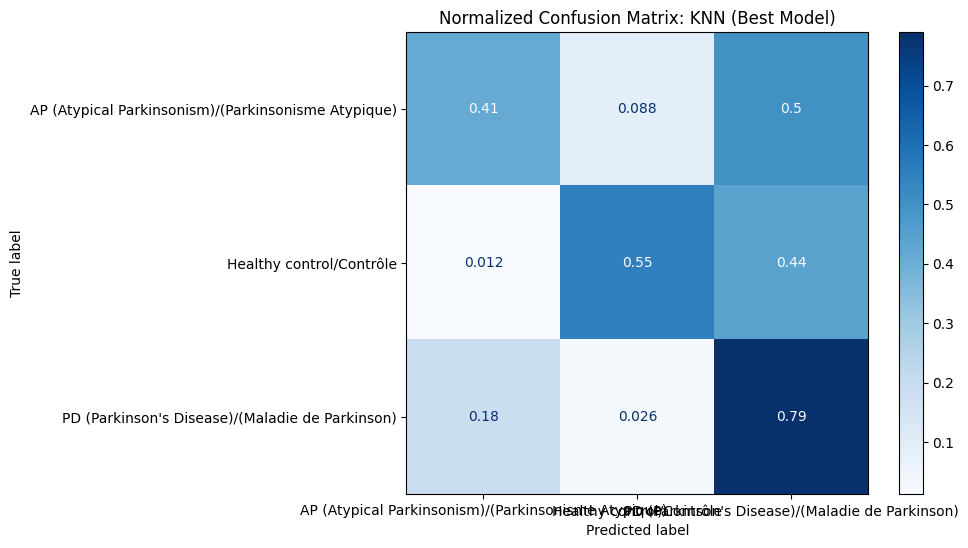


--- Summary Table ---
                 Model  Test Accuracy  Macro F1-Score  AP Recall (Sensitivity)
0  Logistic Regression           0.65            0.50                     0.38
1        Random Forest           0.73            0.52                     0.21
2                  SVM           0.65            0.49                     0.35
3    Gradient Boosting           0.72            0.52                     0.26
4                  KNN           0.77            0.56                     0.41


/var/folders/3_/2m8__4hx1kggyw79jcy4ykkr0000gn/T/ipykernel_99871/3102945989.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Macro F1-Score", data=df_results, palette="viridis")


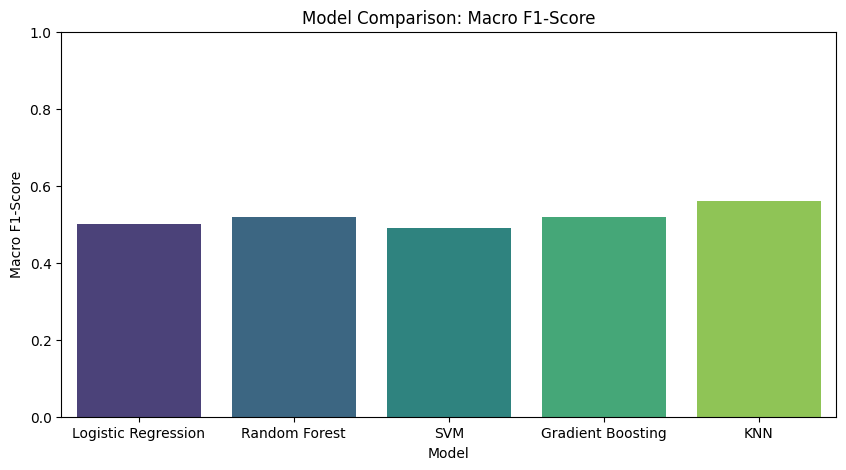

In [23]:
##Final Analysis (The Results)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Confusion Matrix for the Winner (KNN) ---
best_knn = best_models['KNN']
y_pred_knn = best_knn.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax,
    normalize='true' # Shows percentages
)
plt.title("Normalized Confusion Matrix: KNN (Best Model)")
plt.show()

# --- 2. Summary Table of Model Performance ---
results_data = {
    "Model": ["Logistic Regression", "Random Forest", "SVM", "Gradient Boosting", "KNN"],
    "Test Accuracy": [0.65, 0.73, 0.65, 0.72, 0.77],
    "Macro F1-Score": [0.50, 0.52, 0.49, 0.52, 0.56],
    "AP Recall (Sensitivity)": [0.38, 0.21, 0.35, 0.26, 0.41]
}

df_results = pd.DataFrame(results_data)
print("\n--- Summary Table ---")
print(df_results)

# Plotting the comparison
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Macro F1-Score", data=df_results, palette="viridis")
plt.ylim(0, 1)
plt.title("Model Comparison: Macro F1-Score")
plt.show()